# Recommendation Systems Lesson

This notebook implements a complete recommendation system workflow using the MovieLens 100K dataset.

## Learning Objectives

1. Load and explore recommendation system data
2. Implement temporal data splitting
3. Build baseline recommendation models
4. Train ALS (Alternating Least Squares) matrix factorization model
5. Evaluate models using Recall@K, NDCG@K, and Precision@K
6. Generate recommendation artifacts and validate results

## Dataset

- **MovieLens 100K**: 100,000 ratings from 943 users on 1,682 movies
- Download from: https://grouplens.org/datasets/movielens/100k/

## 1. Setup and Imports

In [1]:
import sys
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Set up paths (notebook is in notebooks/ directory)
NOTEBOOK_DIR = Path().resolve()
PROJECT_ROOT = NOTEBOOK_DIR.parent
SRC_DIR = PROJECT_ROOT / 'src'
DATA_DIR = PROJECT_ROOT / 'ml-100k'
ARTIFACTS_DIR = PROJECT_ROOT / 'artifacts'
ARTIFACTS_DIR.mkdir(exist_ok=True)

# Add src to path
sys.path.insert(0, str(SRC_DIR))

from data_loader import load_movielens_100k
from data_split import time_based_split
from baselines import PopularityModel
from als_model import ALSModel
from evaluation import evaluate_model, save_evaluation_results

print(f"Project root: {PROJECT_ROOT}")
print(f"Data directory: {DATA_DIR}")
print(f"Artifacts directory: {ARTIFACTS_DIR}")

# Check environment
print(f"\nPython version: {sys.version}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")

# Verify data directory exists
if not DATA_DIR.exists():
    print(f"\nWARNING: Data directory not found: {DATA_DIR}")
    print("Please run: python setup_data.py")
    print("Or download MovieLens 100K manually and extract to 'ml-100k' folder")
else:
    print(f"\nData directory found: {DATA_DIR}")

Project root: /Users/andrew/projects/aise_W22D1_recommendation_systems
Data directory: /Users/andrew/projects/aise_W22D1_recommendation_systems/ml-100k
Artifacts directory: /Users/andrew/projects/aise_W22D1_recommendation_systems/artifacts

Python version: 3.10.19 | packaged by conda-forge | (main, Oct 22 2025, 22:46:49) [Clang 19.1.7 ]
Pandas version: 2.2.3
NumPy version: 1.26.4

Please run: python setup_data.py
Or download MovieLens 100K manually and extract to 'ml-100k' folder


## 2. Data Loading

In [3]:
# Load MovieLens 100K dataset
ratings_df, items_df = load_movielens_100k(str(DATA_DIR))

# Display basic statistics
print("\n=== Ratings Data ===")
print(ratings_df.head())
print(f"\nShape: {ratings_df.shape}")
print(f"Date range: {ratings_df['timestamp'].min()} to {ratings_df['timestamp'].max()}")

print("\n=== Items Data ===")
print(items_df.head())
print(f"\nShape: {items_df.shape}")

# Merge for exploration
ratings_with_titles = ratings_df.merge(items_df[['item_id', 'title']], on='item_id', how='left')
print("\n=== Sample Ratings with Titles ===")
print(ratings_with_titles.head(10))

Loaded 100,000 ratings from 943 users
Loaded 1,682 items
Rating range: 1.0 - 5.0

=== Ratings Data ===
   user_id  item_id  rating           timestamp
0      196      242       3 1997-12-04 15:55:49
1      186      302       3 1998-04-04 19:22:22
2       22      377       1 1997-11-07 07:18:36
3      244       51       2 1997-11-27 05:02:03
4      166      346       1 1998-02-02 05:33:16

Shape: (100000, 4)
Date range: 1997-09-20 03:05:10 to 1998-04-22 23:10:38

=== Items Data ===
   item_id              title release_date  video_release_date  \
0        1   Toy Story (1995)  01-Jan-1995                 NaN   
1        2   GoldenEye (1995)  01-Jan-1995                 NaN   
2        3  Four Rooms (1995)  01-Jan-1995                 NaN   
3        4  Get Shorty (1995)  01-Jan-1995                 NaN   
4        5     Copycat (1995)  01-Jan-1995                 NaN   

                                            imdb_url  unknown  Action  \
0  http://us.imdb.com/M/title-exact?Toy%20St

## 3. Data Exploration

/var/folders/94/lh1w7s0n5yvfsgh41zbtvn900000gn/T/ipykernel_38051/1597177521.py:13: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  ratings_df.set_index('timestamp')['rating'].resample('M').count().plot()


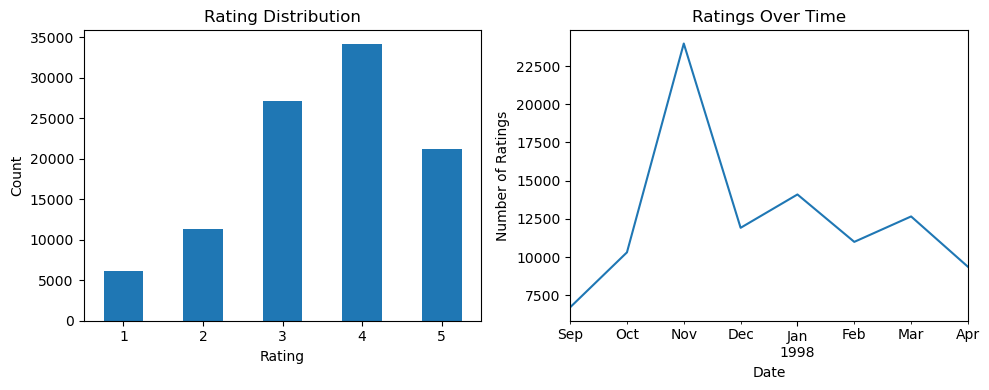

=== Dataset Statistics ===
Total ratings: 100,000
Unique users: 943
Unique items: 1,682
Average rating: 3.53
Rating sparsity: 93.70%


In [4]:
# Rating distribution
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
ratings_df['rating'].value_counts().sort_index().plot(kind='bar')
plt.title('Rating Distribution')
plt.xlabel('Rating')
plt.ylabel('Count')
plt.xticks(rotation=0)

# Ratings over time
plt.subplot(1, 2, 2)
ratings_df.set_index('timestamp')['rating'].resample('M').count().plot()
plt.title('Ratings Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Ratings')

plt.tight_layout()
plt.show()

# Statistics
print("=== Dataset Statistics ===")
print(f"Total ratings: {len(ratings_df):,}")
print(f"Unique users: {ratings_df['user_id'].nunique():,}")
print(f"Unique items: {ratings_df['item_id'].nunique():,}")
print(f"Average rating: {ratings_df['rating'].mean():.2f}")
print(f"Rating sparsity: {(1 - len(ratings_df) / (ratings_df['user_id'].nunique() * ratings_df['item_id'].nunique())) * 100:.2f}%")

## 4. Temporal Data Splitting

**Critical**: We split data temporally to ensure training data only contains interactions that occurred **before** validation and test sets. This simulates real-world recommendation scenarios.

In [5]:
# Split data temporally (70% train, 15% val, 15% test)
train_df, val_df, test_df = time_based_split(
    ratings_df,
    train_ratio=0.7,
    val_ratio=0.15,
    test_ratio=0.15
)

# Verify temporal ordering
print("\n=== Temporal Split Validation ===")
print(f"Max training time: {train_df['timestamp'].max()}")
print(f"Min validation time: {val_df['timestamp'].min()}")
print(f"Max validation time: {val_df['timestamp'].max()}")
print(f"Min test time: {test_df['timestamp'].min()}")

assert train_df['timestamp'].max() < val_df['timestamp'].min(), "Temporal leakage detected!"
assert val_df['timestamp'].max() < test_df['timestamp'].min(), "Temporal leakage detected!"
print("\nTemporal ordering validated: train < val < test")

Temporal split completed:
  Training: 69,997 interactions (70.0%)
  Validation: 15,003 interactions (15.0%)
  Test: 15,000 interactions (15.0%)
  Training time range: 1997-09-20 03:05:10 to 1998-02-09 15:46:04
  Validation time range: 1998-02-09 15:47:51 to 1998-03-27 22:06:54
  Test time range: 1998-03-27 22:07:03 to 1998-04-22 23:10:38

=== Temporal Split Validation ===
Max training time: 1998-02-09 15:46:04
Min validation time: 1998-02-09 15:47:51
Max validation time: 1998-03-27 22:06:54
Min test time: 1998-03-27 22:07:03

Temporal ordering validated: train < val < test


## 5. Baseline Model: Popularity

A simple baseline that recommends the most popular items (by interaction count or average rating). This should run in < 5 seconds.

In [6]:
import time

# Train popularity model
print("Training popularity baseline...")
start_time = time.time()

popularity_model = PopularityModel(ranking_method='count')
popularity_model.fit(train_df)

train_time = time.time() - start_time
print(f"Training time: {train_time:.2f} seconds")
assert train_time < 5.0, f"Popularity model should run in < 5 seconds, took {train_time:.2f}s"

# Generate recommendations for test users
test_users = test_df['user_id'].unique()[:100]  # Sample 100 users for speed
print(f"\nGenerating recommendations for {len(test_users)} test users...")

popularity_recs = popularity_model.predict(user_ids=test_users.tolist(), k=10)
print(f"Generated {len(popularity_recs)} recommendations")
print("\nSample recommendations:")
print(popularity_recs.head(10))

Training popularity baseline...
Fitted popularity model with 1573 items
Top 5 items: [50, 100, 181, 294, 1]
Training time: 0.00 seconds

Generating recommendations for 100 test users...
Generated 1000 recommendations

Sample recommendations:
   user_id  item_id  score  rank
0      339       50    428     1
1      339      100    387     2
2      339      181    381     3
3      339      294    349     4
4      339        1    342     5
5      339      258    339     6
6      339      288    330     7
7      339      121    329     8
8      339      286    327     9
9      339      174    310    10


## 6. ALS Model: Matrix Factorization

Alternating Least Squares (ALS) learns latent factors for users and items. Default configuration: factors=32, iterations=10, optimized for CPU (~5-10 minutes).

In [7]:
# Train ALS model
print("Training ALS model...")
print("Configuration: factors=32, iterations=10, CPU-optimized")
start_time = time.time()

als_model = ALSModel(factors=32, iterations=10, random_state=42)
als_model.fit(train_df)

train_time = time.time() - start_time
print(f"\nTraining time: {train_time:.1f} seconds ({train_time/60:.1f} minutes)")

# Save factors
als_model.save_factors(str(ARTIFACTS_DIR))
print(f"\nModel factors saved to {ARTIFACTS_DIR}")

Training ALS model...
Configuration: factors=32, iterations=10, CPU-optimized
Building interaction matrix from 69,997 interactions...
Matrix shape: 674 users × 1,573 items
Training ALS model (factors=32, iterations=10)...


/Users/andrew/mambaforge/lib/python3.10/site-packages/implicit/cpu/als.py:95: RuntimeWarning: OpenBLAS is configured to use 10 threads. It is highly recommended to disable its internal threadpool by setting the environment variable 'OPENBLAS_NUM_THREADS=1' or by calling 'threadpoolctl.threadpool_limits(1, "blas")'. Having OpenBLAS use a threadpool can lead to severe performance issues here.
  check_blas_config()


  0%|          | 0/10 [00:00<?, ?it/s]

Training complete. User factors shape: (674, 32)
Item factors shape: (1573, 32)

Training time: 0.5 seconds (0.0 minutes)
Saved user factors to /Users/andrew/projects/aise_W22D1_recommendation_systems/artifacts/user_factors.npy
Saved item factors to /Users/andrew/projects/aise_W22D1_recommendation_systems/artifacts/item_factors.npy

Model factors saved to /Users/andrew/projects/aise_W22D1_recommendation_systems/artifacts


In [8]:
# Generate recommendations for test users
print(f"Generating recommendations for {len(test_users)} test users...")

# Get items each user has already interacted with in training (to exclude)
train_items_by_user = train_df.groupby('user_id')['item_id'].apply(set).to_dict()

als_recs = []
for user_id in test_users:
    exclude_items = train_items_by_user.get(user_id, set())
    user_recs = als_model.predict(
        user_ids=[user_id],
        k=10,
        exclude_items=list(exclude_items) if exclude_items else None
    )
    als_recs.append(user_recs)

als_recs_df = pd.concat(als_recs, ignore_index=True)
print(f"Generated {len(als_recs_df)} recommendations")
print("\nSample recommendations:")
print(als_recs_df.head(10))

Generating recommendations for 100 test users...
Generated 170 recommendations

Sample recommendations:
   user_id  item_id     score  rank
0       13       57  1.421182     1
1       13     1109  1.407964     2
2       13     1079  1.338896     3
3       13     1093  1.310450     4
4       13      726  1.279115     5
5       13      537  1.272921     6
6       13      556  1.267743     7
7       13     1264  1.264194     8
8       13     1194  1.258952     9
9       13     1239  1.250338    10


## 7. Model Evaluation

Evaluate both models using Recall@K, NDCG@K, and Precision@K metrics.

In [9]:
# Evaluate popularity model
print("=== Popularity Model Evaluation ===")
popularity_results = evaluate_model(
    popularity_recs,
    test_df[test_df['user_id'].isin(test_users)],
    train_df=train_df,
    k_values=[5, 10, 20]
)
popularity_results['model'] = 'popularity'

print("\nMetrics:")
for metric, value in popularity_results['metrics'].items():
    print(f"  {metric}: {value:.4f}")

print("\nSanity Checks:")
for check, value in popularity_results['sanity_checks'].items():
    print(f"  {check}: {value}")

# Verify Recall@10 is not zero
assert popularity_results['sanity_checks']['recall@10_not_zero'], \
    "Recall@10 is zero - check model implementation!"
print("\nRecall@10 validation passed")

=== Popularity Model Evaluation ===

Metrics:
  recall@5: 0.0237
  precision@5: 0.3020
  ndcg@5: 0.3125
  recall@10: 0.0584
  precision@10: 0.3170
  ndcg@10: 0.3202
  recall@20: 0.0584
  precision@20: 0.3170
  ndcg@20: 0.2293

Sanity Checks:
  recall@10_not_zero: True
  recall@10_value: 0.058389561516392546
  num_recommendations: 1000
  num_users: 100
  num_items: 10

Recall@10 validation passed


In [10]:
# Evaluate ALS model
print("=== ALS Model Evaluation ===")
als_results = evaluate_model(
    als_recs_df,
    test_df[test_df['user_id'].isin(test_users)],
    train_df=train_df,
    k_values=[5, 10, 20]
)
als_results['model'] = 'als'

print("\nMetrics:")
for metric, value in als_results['metrics'].items():
    print(f"  {metric}: {value:.4f}")

print("\nSanity Checks:")
for check, value in als_results['sanity_checks'].items():
    print(f"  {check}: {value}")

# Verify Recall@10 is not zero
assert als_results['sanity_checks']['recall@10_not_zero'], \
    "Recall@10 is zero - check model implementation!"
print("\nRecall@10 validation passed")

=== ALS Model Evaluation ===

Metrics:
  recall@5: 0.0450
  precision@5: 0.0588
  ndcg@5: 0.0626
  recall@10: 0.1027
  precision@10: 0.0824
  ndcg@10: 0.0976
  recall@20: 0.1027
  precision@20: 0.0824
  ndcg@20: 0.0880

Sanity Checks:
  recall@10_not_zero: True
  recall@10_value: 0.10274732270530589
  num_recommendations: 170
  num_users: 17
  num_items: 154

Recall@10 validation passed


## 8. Leakage Detection

Verify that recommendations don't include training items for the same users (temporal leakage check).

In [11]:
print("=== Leakage Check: Popularity Model ===")
print(popularity_results['leakage_check'])

print("\n=== Leakage Check: ALS Model ===")
print(als_results['leakage_check'])

# Note: Some leakage is expected for popularity model (it recommends popular items
# that users may have seen in training). The key check is temporal ordering.
assert popularity_results['leakage_check']['temporal_order_valid'], \
    "Temporal ordering violated!"
assert als_results['leakage_check']['temporal_order_valid'], \
    "Temporal ordering violated!"

print("\nTemporal ordering validated for both models")

=== Leakage Check: Popularity Model ===
{'has_leakage': True, 'leakage_count': 106, 'leakage_rate': 0.106, 'temporal_order_valid': True, 'total_recommendations': 1000}

=== Leakage Check: ALS Model ===
{'has_leakage': False, 'leakage_count': 0, 'leakage_rate': 0.0, 'temporal_order_valid': True, 'total_recommendations': 170}

Temporal ordering validated for both models


## 9. Generate Artifacts

Save evaluation results, model factors, and recommendation candidates.

In [15]:
# Combine evaluation results
all_results = {
    'models': [popularity_results, als_results],
    'summary': {
        'popularity': {
            'recall@10': popularity_results['metrics']['recall@10'],
            'ndcg@10': popularity_results['metrics']['ndcg@10']
        },
        'als': {
            'recall@10': als_results['metrics']['recall@10'],
            'ndcg@10': als_results['metrics']['ndcg@10']
        }
    }
}

# Save evaluation results
eval_path = ARTIFACTS_DIR / 'offline_eval_rec.json'
save_evaluation_results(all_results, str(eval_path))
print(f"Saved evaluation results to {eval_path}")

# Save recommendation candidates (combine both models)
all_recs = pd.concat([
    popularity_recs.assign(model='popularity'),
    als_recs_df.assign(model='als')
], ignore_index=True)

# Ensure required columns: user_id, item_id, score, rank
recs_path = ARTIFACTS_DIR / 'rec_candidates.parquet'
all_recs[['user_id', 'item_id', 'score', 'rank']].to_parquet(recs_path, index=False, engine='fastparquet')
print(f"Saved recommendation candidates to {recs_path}")
print(f"  Shape: {all_recs.shape}")
print(f"  Columns: {list(all_recs.columns)}")

# Verify artifacts
print("\n=== Artifact Verification ===")
print(f"  {eval_path.exists()}: offline_eval_rec.json")
print(f"  {(ARTIFACTS_DIR / 'user_factors.npy').exists()}: user_factors.npy")
print(f"  {(ARTIFACTS_DIR / 'item_factors.npy').exists()}: item_factors.npy")
print(f"  {recs_path.exists()}: rec_candidates.parquet")

Saved evaluation results to /Users/andrew/projects/aise_W22D1_recommendation_systems/artifacts/offline_eval_rec.json
Saved evaluation results to /Users/andrew/projects/aise_W22D1_recommendation_systems/artifacts/offline_eval_rec.json
Saved recommendation candidates to /Users/andrew/projects/aise_W22D1_recommendation_systems/artifacts/rec_candidates.parquet
  Shape: (1170, 5)
  Columns: ['user_id', 'item_id', 'score', 'rank', 'model']

=== Artifact Verification ===
  True: offline_eval_rec.json
  True: user_factors.npy
  True: item_factors.npy
  True: rec_candidates.parquet


## 10. Model Comparison

Compare performance of baseline vs. ALS model.

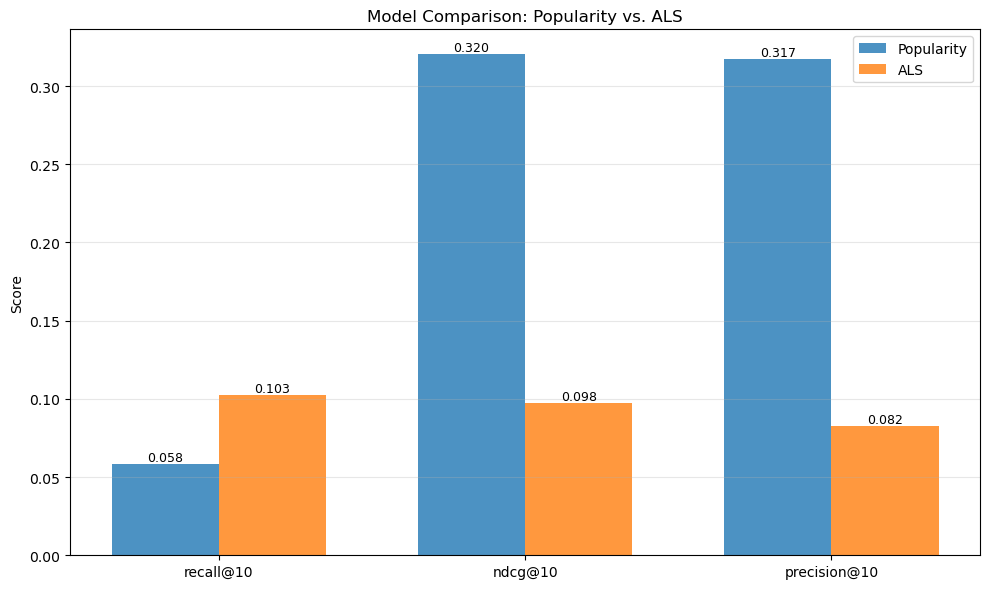


=== Summary ===
Popularity - Recall@10: 0.0584, NDCG@10: 0.3202
ALS - Recall@10: 0.1027, NDCG@10: 0.0976


In [16]:
# Create comparison visualization
metrics_to_compare = ['recall@10', 'ndcg@10', 'precision@10']
models = ['popularity', 'als']
values = {
    'popularity': [popularity_results['metrics'][m] for m in metrics_to_compare],
    'als': [als_results['metrics'][m] for m in metrics_to_compare]
}

x = np.arange(len(metrics_to_compare))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
bars1 = ax.bar(x - width/2, values['popularity'], width, label='Popularity', alpha=0.8)
bars2 = ax.bar(x + width/2, values['als'], width, label='ALS', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Model Comparison: Popularity vs. ALS')
ax.set_xticks(x)
ax.set_xticklabels(metrics_to_compare)
ax.legend()
ax.grid(axis='y', alpha=0.3)

# Add value labels on bars
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2., height,
                f'{height:.3f}',
                ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

print("\n=== Summary ===")
print(f"Popularity - Recall@10: {popularity_results['metrics']['recall@10']:.4f}, "
      f"NDCG@10: {popularity_results['metrics']['ndcg@10']:.4f}")
print(f"ALS - Recall@10: {als_results['metrics']['recall@10']:.4f}, "
      f"NDCG@10: {als_results['metrics']['ndcg@10']:.4f}")

## Summary

**Completed Tasks:**
1. Loaded and explored MovieLens 100K dataset
2. Performed temporal data splitting (train < val < test)
3. Trained popularity baseline model (< 5 seconds)
4. Trained ALS model (factors=32, iterations=10, CPU-optimized)
5. Evaluated models with Recall@K, NDCG@K, Precision@K
6. Validated no temporal leakage
7. Generated all required artifacts:
   - `artifacts/offline_eval_rec.json`
   - `artifacts/user_factors.npy`
   - `artifacts/item_factors.npy`
   - `artifacts/rec_candidates.parquet`

**Sanity Checks Passed:**
- Recall@10 > 0 for both models
- Temporal ordering validated (no leakage)
- All artifacts generated successfully

## References

- [implicit library documentation](https://github.com/benfred/implicit)
- [PyTorch Get Started (Locally)](https://pytorch.org/get-started/locally/)
- [scikit-learn NDCG metric](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.ndcg_score.html)
- [MovieLens Dataset](https://grouplens.org/datasets/movielens/)